# 🧮 Neural SDE Project — Fase 1
## GBM Foundations & Stylized Facts
### Data: Saham IDX (Bank + Tambang) & Altcoin | 2018 → Mei 2026

---
**Aset yang dianalisis:**

| Kategori | Ticker | Nama |
|----------|--------|------|
| 🏦 Bank | `BMRI.JK` | Bank Mandiri |
| 🏦 Bank | `BBRI.JK` | Bank BRI |
| 🏦 Bank Syariah | `BRIS.JK` | Bank Syariah Indonesia |
| ⛏️ Tambang | `ADRO.JK` | Adaro Energy (batubara) |
| ⛏️ Tambang | `ANTM.JK` | Aneka Tambang (nikel & emas) |
| 🪙 Altcoin | `SOL-USD` | Solana |
| 🪙 Altcoin | `XRP-USD` | XRP |

**Tujuan fase ini:**
1. Simulasi GBM dari scratch — memahami Ito's Lemma
2. Implementasi Euler–Maruyama (dasar cara kerja `torchsde`)
3. Analisis stylized facts per aset
4. Membuktikan GBM tidak cukup → motivasi Neural SDE

> ▶️ **Runtime → Run all** untuk menjalankan seluruh notebook sekaligus.


## ⚙️ 1. Setup

In [6]:
# Install (sekali per sesi Colab)
%pip install yfinance matplotlib scipy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})
np.random.seed(42)
print("✅ Setup selesai!")


Note: you may need to restart the kernel to use updated packages.
✅ Setup selesai!


## 📥 2. Download Data Nyata (2018 → Mei 2026)

Data diambil langsung dari Yahoo Finance via `yfinance`.
Semua harga sudah *adjusted* untuk stock split dan dividen.


In [7]:
TICKERS = {
    'BMRI.JK' : ('🏦 Bank Mandiri',              'steelblue'),
    'BBRI.JK' : ('🏦 Bank BRI',                  'royalblue'),
    'BRIS.JK' : ('🏦 Bank Syariah Indonesia',     'dodgerblue'),
    'ADRO.JK' : ('⛏️  Adaro Energy (batubara)',   'saddlebrown'),
    'ANTM.JK' : ('⛏️  Aneka Tambang (nikel/emas)','goldenrod'),
    'SOL-USD' : ('🪙 Solana',                     'mediumpurple'),
    'XRP-USD' : ('🪙 XRP',                        'mediumseagreen'),
}

START = '2018-01-01'
END   = '2026-05-12'   # update sesuai hari ini

assets = {}
print(f"Mengunduh data {START} → {END}...\n")
for ticker, (label, color) in TICKERS.items():
    df  = yf.download(ticker, start=START, end=END,
                      auto_adjust=True, progress=False)
    px  = df['Close'].squeeze().dropna()
    ret = np.diff(np.log(px.values))

    assets[ticker] = {
        'label'  : label,
        'color'  : color,
        'prices' : px,
        'returns': ret,
    }
    ann_vol  = ret.std()  * np.sqrt(252 if 'JK' in ticker else 365)
    ann_ret  = ret.mean() * (252     if 'JK' in ticker else 365)
    kurt     = stats.kurtosis(ret)
    print(f"{label}")
    print(f"  Periode : {px.index[0].date()} → {px.index[-1].date()}  ({len(px):,} hari)")
    print(f"  Ann. Return : {ann_ret:+.1%}   Ann. Vol : {ann_vol:.1%}   Kurtosis : {kurt:.2f}")
    print()

print("✅ Download selesai!")


Mengunduh data 2018-01-01 → 2026-05-12...

🏦 Bank Mandiri
  Periode : 2018-01-01 → 2026-05-11  (2,048 hari)
  Ann. Return : +6.7%   Ann. Vol : 33.3%   Kurtosis : 4.29

🏦 Bank BRI
  Periode : 2018-01-01 → 2026-05-11  (2,048 hari)
  Ann. Return : +5.3%   Ann. Vol : 32.4%   Kurtosis : 5.65

🏦 Bank Syariah Indonesia
  Periode : 2018-05-09 → 2026-05-11  (1,955 hari)
  Ann. Return : +16.4%   Ann. Vol : 51.5%   Kurtosis : 12.69

⛏️  Adaro Energy (batubara)
  Periode : 2018-01-01 → 2026-05-11  (2,047 hari)
  Ann. Return : +20.7%   Ann. Vol : 45.5%   Kurtosis : 8.74

⛏️  Aneka Tambang (nikel/emas)
  Periode : 2018-01-01 → 2026-05-11  (2,048 hari)
  Ann. Return : +24.5%   Ann. Vol : 48.6%   Kurtosis : 4.80

🪙 Solana
  Periode : 2020-04-10 → 2026-05-11  (2,223 hari)
  Ann. Return : +76.0%   Ann. Vol : 119.8%   Kurtosis : 7.51

🪙 XRP
  Periode : 2018-01-01 → 2026-05-11  (3,053 hari)
  Ann. Return : -5.8%   Ann. Vol : 101.4%   Kurtosis : 16.91

✅ Download selesai!


## 📊 3. Overview Harga & Return Distribution

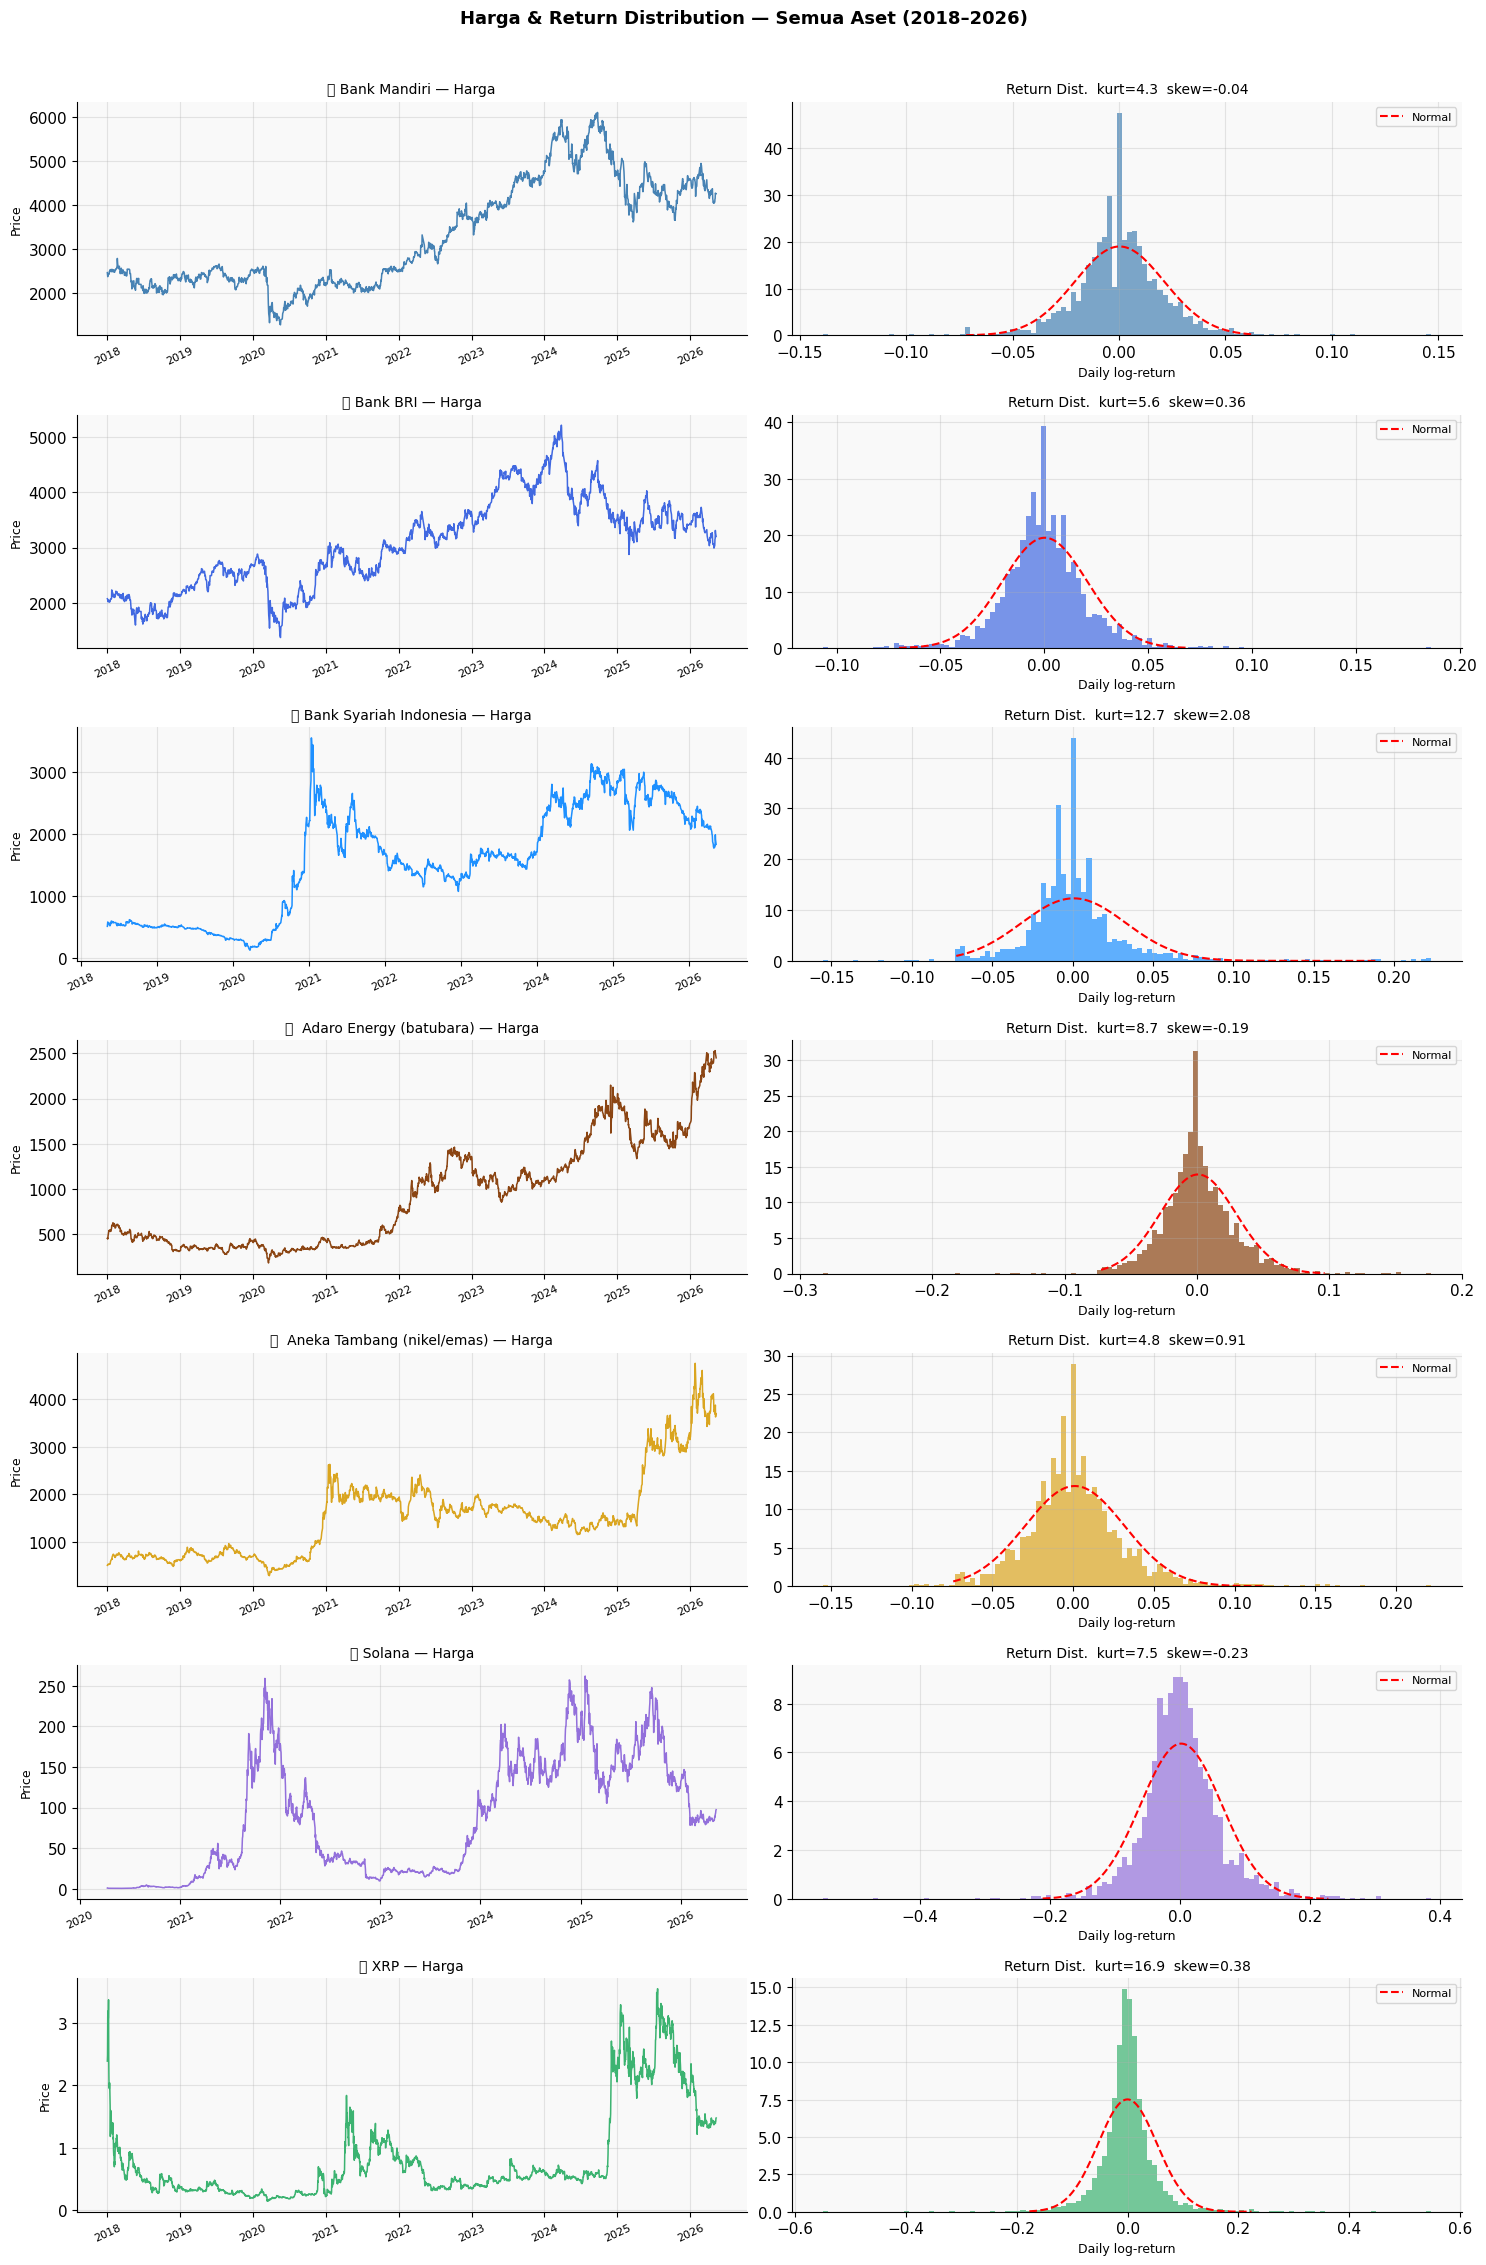


📌 Amati: semua aset punya ekor lebih tebal dari distribusi Normal (fat tails)
   → ini yang TIDAK bisa ditangkap GBM, tapi bisa oleh Neural SDE!


In [8]:
fig, axes = plt.subplots(len(assets), 2, figsize=(15, 3.2 * len(assets)))
fig.suptitle('Harga & Return Distribution — Semua Aset (2018–2026)',
             fontsize=13, fontweight='bold', y=1.01)

for i, (ticker, d) in enumerate(assets.items()):
    px  = d['prices']
    ret = d['returns']
    col = d['color']

    # Harga
    ax = axes[i, 0]
    ax.plot(px.index, px.values, color=col, linewidth=1.1)
    ax.set_title(f"{d['label']} — Harga", fontsize=10)
    ax.set_ylabel('Price', fontsize=9)
    ax.tick_params(axis='x', rotation=25, labelsize=8)

    # Return distribution
    ax = axes[i, 1]
    ax.hist(ret, bins=120, density=True, color=col, alpha=0.7)
    x  = np.linspace(np.percentile(ret,0.5), np.percentile(ret,99.5), 300)
    ax.plot(x, stats.norm.pdf(x, ret.mean(), ret.std()),
            'r--', linewidth=1.5, label='Normal')
    kurt_val = stats.kurtosis(ret)
    skew_val = stats.skew(ret)
    ax.set_title(f"Return Dist.  kurt={kurt_val:.1f}  skew={skew_val:.2f}", fontsize=10)
    ax.set_xlabel('Daily log-return', fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('phase1_overview.png', dpi=130, bbox_inches='tight')
plt.show()
print("\n📌 Amati: semua aset punya ekor lebih tebal dari distribusi Normal (fat tails)")
print("   → ini yang TIDAK bisa ditangkap GBM, tapi bisa oleh Neural SDE!")


## 📐 4. GBM & Ito's Lemma

Model GBM:
$$dS_t = \mu S_t\,dt + \sigma S_t\,dW_t$$

Solusi eksak via **Ito's Lemma** (terapkan $f = \ln S$):
$$S_t = S_0 \cdot \exp\!\Bigl[\bigl(\mu - \tfrac{\sigma^2}{2}\bigr)t + \sigma W_t\Bigr]$$

> **Mengapa ada koreksi $-\sigma^2/2$?**
> Di kalkulus biasa: $(dx)^2 \approx 0$.
> Di kalkulus Itô: $(dW_t)^2 = dt$ *(quadratic variation tidak nol!)*
> Tanpa koreksi ini kita akan **overestimate** nilai ekspektasi harga.

Kalibrasi GBM ke setiap aset, lalu simulasi 1 tahun ke depan.


In [9]:
T      = 1.0
dt     = 1/252
N      = int(T / dt)
N_PATH = 1500

gbm_results = {}

for ticker, d in assets.items():
    ret   = d['returns']
    n_day = 252 if 'JK' in ticker else 365

    mu_hat    = ret.mean() * n_day
    sigma_hat = ret.std()  * np.sqrt(n_day)
    S0        = d['prices'].iloc[-1]

    Z          = np.random.normal(0, 1, (N, N_PATH))
    increments = (mu_hat - 0.5*sigma_hat**2)*dt + sigma_hat*np.sqrt(dt)*Z
    S_paths    = S0 * np.exp(np.vstack([np.zeros(N_PATH),
                                         np.cumsum(increments, axis=0)]))

    S_T_sim  = S_paths[-1].mean()
    S_T_theo = S0 * np.exp(mu_hat * T)

    gbm_results[ticker] = {
        'paths'   : S_paths,
        'mu'      : mu_hat,
        'sigma'   : sigma_hat,
        'S0'      : S0,
        'S_T_sim' : S_T_sim,
        'S_T_theo': S_T_theo,
    }

# Print summary
print(f"{'Ticker':<10} {'μ (ann)':>9} {'σ (ann)':>9} "
      f"{'S0':>10} {'E[S_T] sim':>12} {'E[S_T] theo':>13}")
print("-" * 65)
for t, r in gbm_results.items():
    print(f"{t:<10} {r['mu']:>9.1%} {r['sigma']:>9.1%} "
          f"{r['S0']:>10.2f} {r['S_T_sim']:>12.2f} {r['S_T_theo']:>13.2f}")

print("\n📌 Perhatikan σ crypto (SOL, XRP) vs saham IDX: jauh lebih besar!")
print("   Volatility tinggi = lebih susah dimodel dengan GBM sederhana")


Ticker       μ (ann)   σ (ann)         S0   E[S_T] sim   E[S_T] theo
-----------------------------------------------------------------
BMRI.JK         6.7%     33.3%    4250.00      4550.66       4546.69
BBRI.JK         5.3%     32.4%    3200.00      3349.36       3375.70
BRIS.JK        16.4%     51.5%    1835.00      2132.83       2163.03
ADRO.JK        20.7%     45.5%    2450.00      2973.02       3012.79
ANTM.JK        24.5%     48.6%    3700.00      4753.78       4729.28
SOL-USD        76.0%    119.8%      97.35       213.29        208.23
XRP-USD        -5.8%    101.4%       1.48         1.47          1.39

📌 Perhatikan σ crypto (SOL, XRP) vs saham IDX: jauh lebih besar!
   Volatility tinggi = lebih susah dimodel dengan GBM sederhana


## 🌊 5. Fan of Paths — Proyeksi GBM 1 Tahun ke Depan

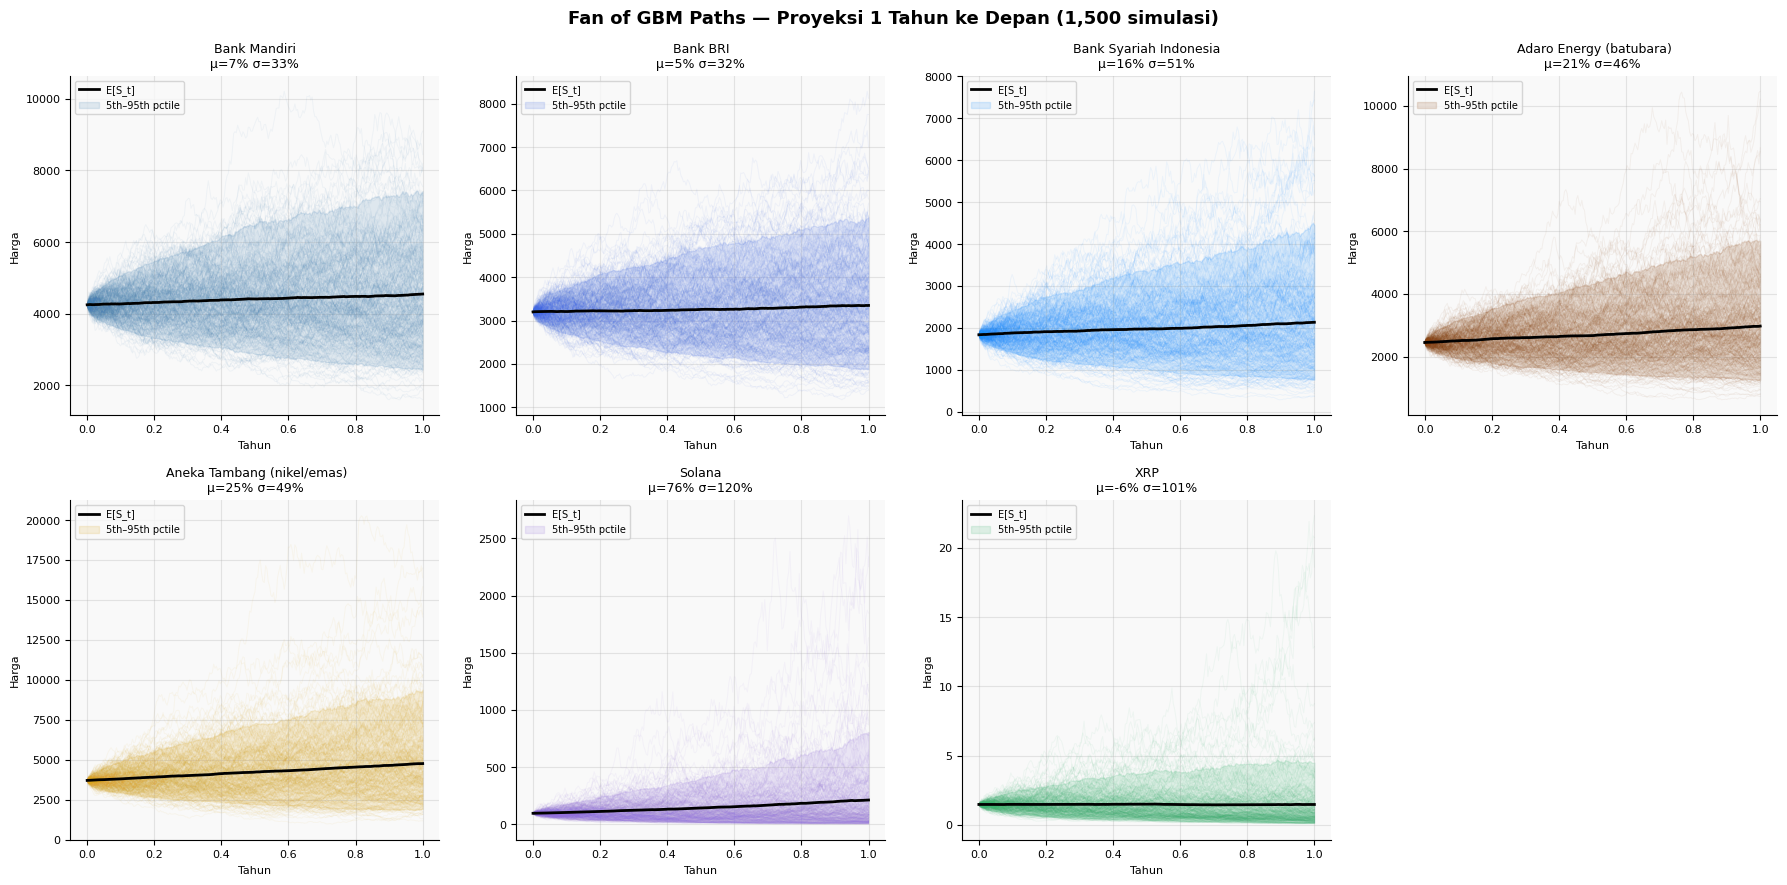

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
time_ax = np.linspace(0, T, N + 1)

for i, (ticker, d) in enumerate(assets.items()):
    ax  = axes[i]
    res = gbm_results[ticker]
    S   = res['paths']
    col = d['color']

    ax.plot(time_ax, S[:, :300], alpha=0.06, color=col, linewidth=0.7)
    ax.plot(time_ax, S.mean(axis=1), color='black', linewidth=2,
            label='E[S_t]', zorder=5)
    ax.fill_between(time_ax,
                    np.percentile(S, 5,  axis=1),
                    np.percentile(S, 95, axis=1),
                    alpha=0.15, color=col, label='5th–95th pctile')

    ax.set_title(f"{d['label'].split(' ',1)[1]}\nμ={res['mu']:.0%} σ={res['sigma']:.0%}",
                 fontsize=9)
    ax.set_xlabel('Tahun', fontsize=8)
    ax.set_ylabel('Harga', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7)

axes[-1].set_visible(False)  # satu slot kosong
fig.suptitle('Fan of GBM Paths — Proyeksi 1 Tahun ke Depan (1,500 simulasi)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase1_fan_paths.png', dpi=130, bbox_inches='tight')
plt.show()


## 🔁 6. Euler–Maruyama

Ketika tidak ada solusi eksak, kita gunakan diskretisasi **Euler–Maruyama**:

$$S_{t+\Delta t} = S_t + \underbrace{\mu S_t\,\Delta t}_{\text{drift}} + \underbrace{\sigma S_t\,\Delta W_t}_{\text{diffusion}}$$

> 🔑 **Koneksi ke Neural SDE:**
> Di Fase 2 nanti, kita ganti $\mu$ dan $\sigma$ dengan **neural network** $f_\theta$ dan $g_\theta$.
> `torchsde` melakukan loop Euler–Maruyama ini tapi dengan **automatic differentiation**
> sehingga gradien bisa mengalir balik melalui SDE solver.


Demo: ⛏️  Adaro Energy (batubara)
Method                   E[S_T]   vs Teori
------------------------------------------
GBM Exact               2973.02   -1.320%
Euler-Maruyama          3000.65   -0.403%
Teori                   3012.79


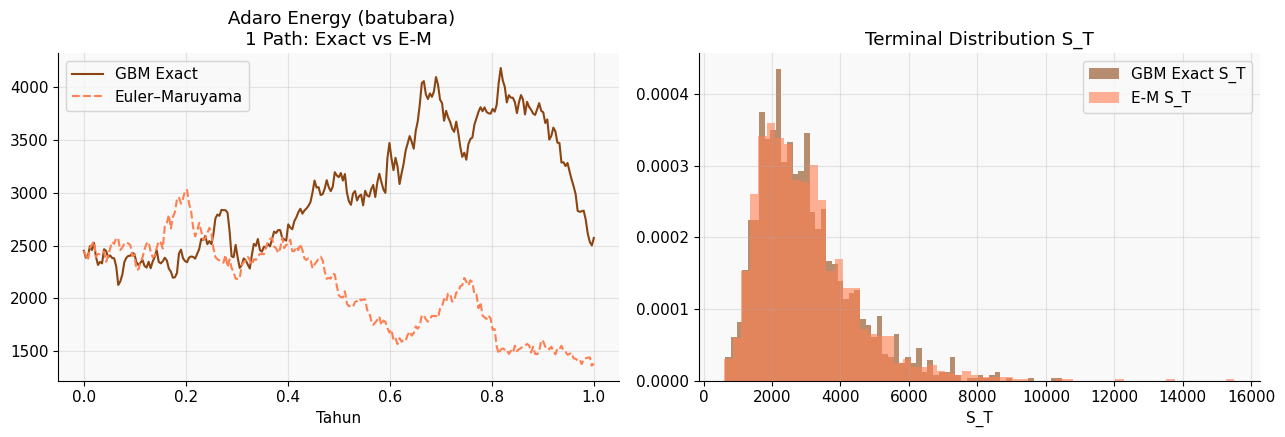

In [11]:
# Demo Euler-Maruyama vs Exact — pakai ADRO sebagai contoh
ticker_demo = 'ADRO.JK'
res  = gbm_results[ticker_demo]
col  = assets[ticker_demo]['color']
mu   = res['mu']
sig  = res['sigma']
S0   = res['S0']

S_em    = np.zeros((N + 1, N_PATH))
S_em[0] = S0
for t in range(N):
    dW         = np.random.normal(0, np.sqrt(dt), N_PATH)
    S_em[t+1]  = S_em[t] + mu*S_em[t]*dt + sig*S_em[t]*dW

print(f"Demo: {assets[ticker_demo]['label']}")
print(f"{'Method':<20} {'E[S_T]':>10} {'vs Teori':>10}")
print("-" * 42)
print(f"{'GBM Exact':<20} {res['S_T_sim']:>10.2f} "
      f"{(res['S_T_sim']-res['S_T_theo'])/res['S_T_theo']:>+9.3%}")
print(f"{'Euler-Maruyama':<20} {S_em[-1].mean():>10.2f} "
      f"{(S_em[-1].mean()-res['S_T_theo'])/res['S_T_theo']:>+9.3%}")
print(f"{'Teori':<20} {res['S_T_theo']:>10.2f}")

# Plot single path comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(time_ax, res['paths'][:, 0],
             label='GBM Exact', color=col, linewidth=1.5)
axes[0].plot(time_ax, S_em[:, 0],
             label='Euler–Maruyama', color='coral', linewidth=1.5, linestyle='--')
axes[0].set_title(f'{assets[ticker_demo]["label"].split(" ",1)[1]}\n1 Path: Exact vs E-M')
axes[0].set_xlabel('Tahun')
axes[0].legend()

axes[1].hist(res['paths'][-1], bins=60, density=True,
             alpha=0.6, color=col, label='GBM Exact S_T')
axes[1].hist(S_em[-1], bins=60, density=True,
             alpha=0.6, color='coral', label='E-M S_T')
axes[1].set_title('Terminal Distribution S_T')
axes[1].set_xlabel('S_T')
axes[1].legend()
plt.tight_layout()
plt.savefig('phase1_euler_maruyama.png', dpi=130, bbox_inches='tight')
plt.show()


## 🔬 7. Stylized Facts — Perbandingan Semua Aset vs GBM

Tiga "stylized facts" yang tidak bisa ditangkap GBM:

| Fact | Definisi | Implikasi |
|------|----------|-----------|
| **Fat tails** | Kurtosis >> 3 | Crash lebih sering dari prediksi GBM |
| **Vol clustering** | ACF(\|r\|²) > 0 | Periode tenang & chaos bergantian |
| **Leverage effect** | Skewness < 0 | Turun lebih ekstrem dari naik |


In [12]:
def compute_stylized_facts(returns, n_day=252):
    """Hitung semua stylized facts dari array daily log-returns."""
    ann_vol  = returns.std() * np.sqrt(n_day)
    ann_ret  = returns.mean() * n_day
    kurt     = stats.kurtosis(returns)        # excess kurtosis (Normal = 0)
    skew     = stats.skew(returns)
    # Volatility clustering: ACF of squared returns at lag 1
    r2 = returns**2
    acf_vol = np.corrcoef(r2[:-1], r2[1:])[0, 1]
    # Leverage effect: correlation between r_t and |r_{t+1}|
    lev = np.corrcoef(returns[:-1], np.abs(returns[1:]))[0, 1]
    # VaR 1% historical
    var1 = np.percentile(returns, 1)
    return dict(ann_ret=ann_ret, ann_vol=ann_vol,
                kurt=kurt, skew=skew,
                acf_vol=acf_vol, lev=lev, var1=var1)

# Tabel perbandingan
rows = []
for ticker, d in assets.items():
    n_day = 252 if 'JK' in ticker else 365
    sf = compute_stylized_facts(d['returns'], n_day)
    rows.append({'Ticker': ticker, 'Nama': d['label'].split(' ', 1)[1], **sf})

df_sf = pd.DataFrame(rows).set_index('Ticker')
df_sf.columns = ['Nama', 'Ann.Return', 'Ann.Vol',
                  'Kurtosis', 'Skewness', 'ACF vol²',
                  'Leverage', 'VaR 1%']

# Format display
fmt = {'Ann.Return': '{:.1%}', 'Ann.Vol': '{:.1%}',
       'Kurtosis': '{:.2f}',   'Skewness': '{:.3f}',
       'ACF vol²': '{:.3f}',   'Leverage': '{:.3f}',
       'VaR 1%': '{:.3%}'}
display(df_sf.style.format(fmt).background_gradient(
    subset=['Kurtosis','ACF vol²'], cmap='YlOrRd'))

print("\n📌 Interpretasi kolom:")
print("  Kurtosis  > 0  → fat tails (semakin besar = semakin 'berbahaya')")
print("  Skewness  < 0  → leverage effect (crash > rally)")
print("  ACF vol²  > 0  → volatility clustering")
print("  VaR 1%         → worst daily loss pada bottom 1%")


,Nama,Ann.Return,Ann.Vol,Kurtosis,Skewness,ACF vol²,Leverage,VaR 1%
Ticker,,,,,,,,
BMRI.JK,Bank Mandiri,6.7%,33.3%,4.29,-0.044,0.280,-0.029,-5.702%
BBRI.JK,Bank BRI,5.3%,32.4%,5.65,0.365,0.281,-0.026,-5.935%
BRIS.JK,Bank Syariah Indonesia,16.4%,51.5%,12.69,2.079,0.265,0.076,-7.084%
ADRO.JK,Adaro Energy (batubara),20.7%,45.5%,8.74,-0.186,0.247,0.034,-6.770%
ANTM.JK,Aneka Tambang (nikel/emas),24.5%,48.6%,4.80,0.906,0.083,-0.001,-7.006%
SOL-USD,Solana,76.0%,119.8%,7.51,-0.232,0.245,-0.017,-16.069%
XRP-USD,XRP,-5.8%,101.4%,16.91,0.382,0.152,0.010,-13.738%



📌 Interpretasi kolom:
  Kurtosis  > 0  → fat tails (semakin besar = semakin 'berbahaya')
  Skewness  < 0  → leverage effect (crash > rally)
  ACF vol²  > 0  → volatility clustering
  VaR 1%         → worst daily loss pada bottom 1%


## 📉 8. Visualisasi Stylized Facts — Volatility Clustering & Fat Tails

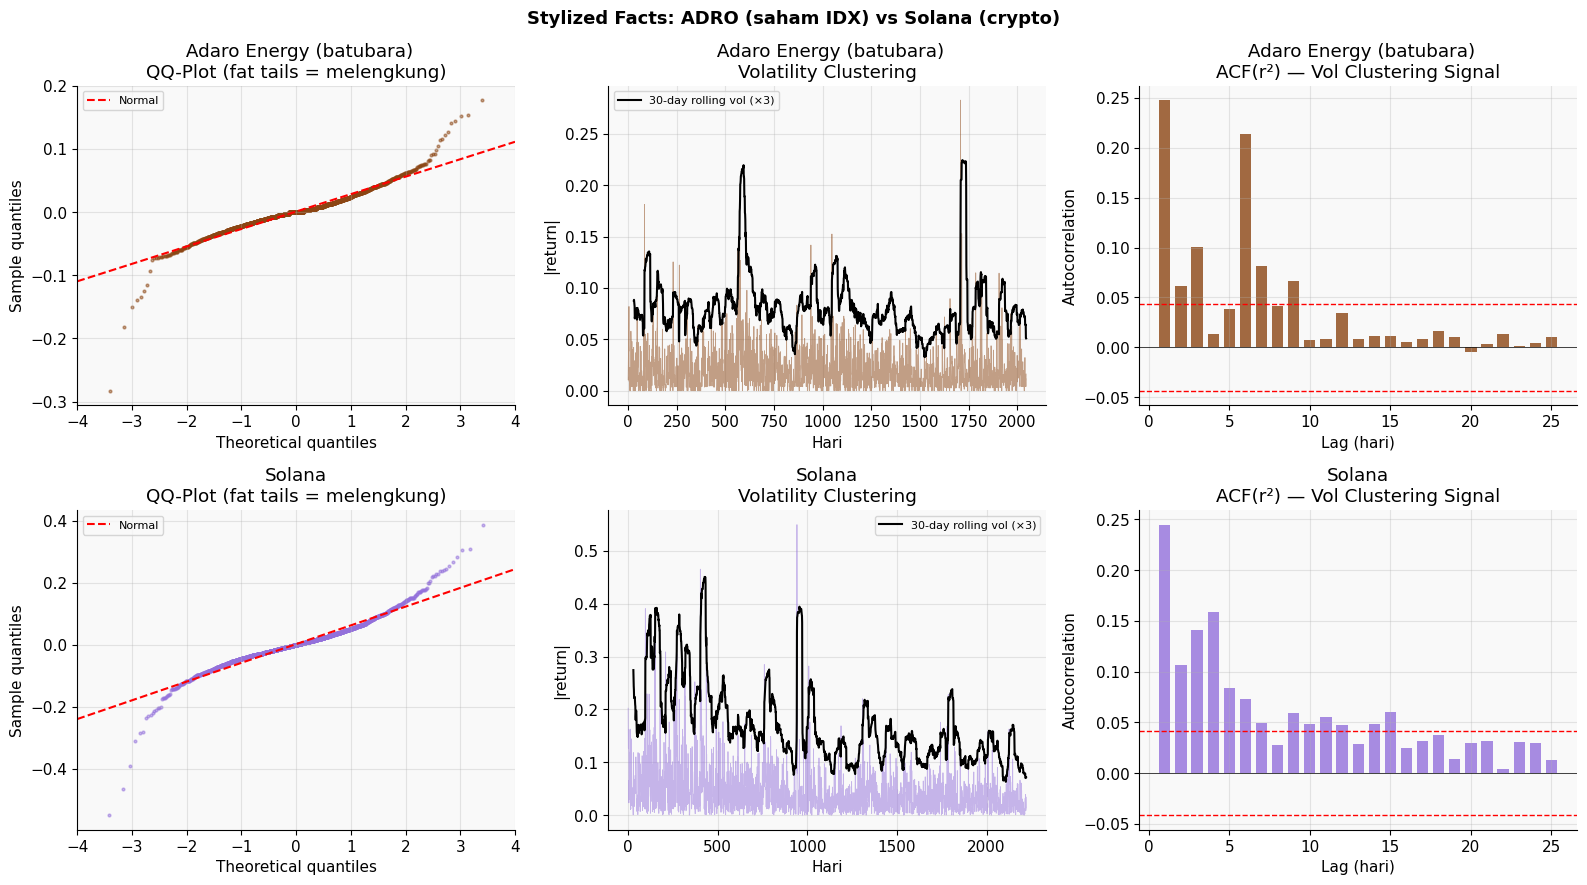

📌 ACF bar yang melebihi garis merah = signifikan → ada volatility clustering
   GBM tidak bisa produce ini → justifikasi kuat untuk Neural SDE!


In [16]:
SHOW = ['ADRO.JK', 'SOL-USD']   # satu saham + satu crypto untuk perbandingan
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Stylized Facts: ADRO (saham IDX) vs Solana (crypto)',
             fontsize=13, fontweight='bold')

for row, ticker in enumerate(SHOW):
    d   = assets[ticker]
    ret = d['returns']
    col = d['color']
    lbl = d['label'].split(' ', 1)[1]

    # --- QQ-plot ---
    ax = axes[row, 0]
    (osm, osr), (slope, intercept, _) = stats.probplot(ret, dist='norm')
    ax.scatter(osm, osr, s=4, alpha=0.5, color=col)
    ax.plot([-4, 4], [intercept + slope*x for x in [-4, 4]],
            'r--', linewidth=1.5, label='Normal')
    ax.set_title(f'{lbl}\nQQ-Plot (fat tails = melengkung)')
    ax.set_xlabel('Theoretical quantiles')
    ax.set_ylabel('Sample quantiles')
    ax.set_xlim(-4, 4)
    ax.legend(fontsize=8)

    # --- Volatility clustering ---
    ax = axes[row, 1]
    t_idx = np.arange(len(ret))
    ax.plot(t_idx, np.abs(ret), alpha=0.5, color=col, linewidth=0.6)
    roll_vol = pd.Series(ret).rolling(30).std().values
    ax.plot(t_idx, roll_vol * 3, color='black', linewidth=1.5,
            label='30-day rolling vol (×3)')
    ax.set_title(f'{lbl}\nVolatility Clustering')
    ax.set_xlabel('Hari')
    ax.set_ylabel('|return|')
    ax.legend(fontsize=8)

    # --- ACF squared returns ---
    ax = axes[row, 2]
    max_lag = 25
    lags    = np.arange(1, max_lag + 1)
    r2      = ret**2
    r2_c    = r2 - r2.mean()
    total_v = r2.var()
    acf_vals = [np.mean(r2_c[:-l] * r2_c[l:]) / total_v for l in lags]
    conf     = 1.96 / np.sqrt(len(ret))
    ax.bar(lags, acf_vals, color=col, alpha=0.8, width=0.7)
    ax.axhline(conf,  color='red', linestyle='--', linewidth=1)
    ax.axhline(-conf, color='red', linestyle='--', linewidth=1)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'{lbl}\nACF(r²) — Vol Clustering Signal')
    ax.set_xlabel('Lag (hari)')
    ax.set_ylabel('Autocorrelation')

plt.tight_layout()
plt.savefig('phase1_stylized_facts.png', dpi=130, bbox_inches='tight')
plt.show()
print("📌 ACF bar yang melebihi garis merah = signifikan → ada volatility clustering")
print("   GBM tidak bisa produce ini → justifikasi kuat untuk Neural SDE!")


## ✅ 9. Ringkasan Fase 1 & Next Steps

In [14]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           KESIMPULAN FASE 1 — NEURAL SDE PROJECT           ║
╚══════════════════════════════════════════════════════════════╝

Yang sudah kamu pelajari:

1. GBM EXACT SOLUTION
   S_t = S_0 · exp[(μ - σ²/2)t + σ W_t]
   → Koreksi -σ²/2 dari Ito's Lemma (quadratic variation ≠ 0)

2. EULER–MARUYAMA
   S_{t+dt} = S_t + μ S_t dt + σ S_t dW_t
   → "For loop" ini yang akan kita ganti neural network di Fase 5!

3. KENAPA GBM TIDAK CUKUP (data kita buktikan):
   ┌────────────────────┬─────┬──────┬──────┬──────┬──────┐
   │ Stylized Fact      │ GBM │ BMRI │ ADRO │ SOL  │ XRP  │
   ├────────────────────┼─────┼──────┼──────┼──────┼──────┤
   │ Fat tails (kurt>0) │  ✗  │  ✓   │  ✓   │  ✓   │  ✓   │
   │ Vol clustering     │  ✗  │  ✓   │  ✓   │  ✓   │  ✓   │
   │ Leverage effect    │  ✗  │  ✓   │  ✓   │  ✓   │  ~   │
   └────────────────────┴─────┴──────┴──────┴──────┴──────┘
   → Neural SDE bisa capture SEMUA ini!

4. NEXT: FASE 2 — torchsde
   dz_t = f_θ(t, z_t) dt + g_θ(t, z_t) dW_t
   di mana f_θ dan g_θ adalah neural network!

File output fase ini:
   phase1_overview.png          ← harga & return distribution
   phase1_fan_paths.png         ← proyeksi GBM 7 aset
   phase1_euler_maruyama.png    ← exact vs Euler-Maruyama
   phase1_stylized_facts.png    ← QQ-plot, vol clustering, ACF
""")



╔══════════════════════════════════════════════════════════════╗
║           KESIMPULAN FASE 1 — NEURAL SDE PROJECT           ║
╚══════════════════════════════════════════════════════════════╝

Yang sudah kamu pelajari:

1. GBM EXACT SOLUTION
   S_t = S_0 · exp[(μ - σ²/2)t + σ W_t]
   → Koreksi -σ²/2 dari Ito's Lemma (quadratic variation ≠ 0)

2. EULER–MARUYAMA
   S_{t+dt} = S_t + μ S_t dt + σ S_t dW_t
   → "For loop" ini yang akan kita ganti neural network di Fase 5!

3. KENAPA GBM TIDAK CUKUP (data kita buktikan):
   ┌────────────────────┬─────┬──────┬──────┬──────┬──────┐
   │ Stylized Fact      │ GBM │ BMRI │ ADRO │ SOL  │ XRP  │
   ├────────────────────┼─────┼──────┼──────┼──────┼──────┤
   │ Fat tails (kurt>0) │  ✗  │  ✓   │  ✓   │  ✓   │  ✓   │
   │ Vol clustering     │  ✗  │  ✓   │  ✓   │  ✓   │  ✓   │
   │ Leverage effect    │  ✗  │  ✓   │  ✓   │  ✓   │  ~   │
   └────────────────────┴─────┴──────┴──────┴──────┴──────┘
   → Neural SDE bisa capture SEMUA ini!

4. NEXT: FASE 2 